# Importing Libraries and Reading our Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
df= pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Pre-Processing our dataset

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [5]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
print("Class Distribution:\n", df['Class'].value_counts())

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0].sample(len(fraud))  # Undersampling to balance the dataset
balanced_df = pd.concat([fraud, non_fraud])
print(balanced_df)

            Time        V1        V2        V3        V4        V5        V6  \
541        406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623        472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920      4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
6108      6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329      7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   
...          ...       ...       ...       ...       ...       ...       ...   
159806  112982.0  2.127204 -0.168670 -1.765445  0.043647  0.371432 -0.581626   
194786  130755.0  2.257688 -1.407605 -0.921245 -1.604483 -1.093003 -0.321836   
178891  123830.0 -3.084566 -3.590180  0.894085  0.100440  0.693725 -1.372163   
168937  119448.0 -1.187309 -0.806906  1.321202 -2.453571 -0.010215  1.745887   
179170  123954.0  0.258093  1.317815 -1.432764  0.804524  2.250029  0.147781   

              V7        V8        V9  .

# Applying PCA

In [8]:
import pandas as pd
from sklearn.decomposition import PCA

# Assuming balanced_df is already prepared
time_col = 'Time'
amount_col = 'Amount'
target_col = 'Class'

# Select features for PCA
features = [col for col in balanced_df.columns if col not in [time_col, amount_col, target_col]]

# Apply PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(balanced_df[features])

# Create PCA DataFrame
pca_columns = ['PC1', 'PC2', 'PC3']
pca_df = pd.DataFrame(principal_components, columns=pca_columns, index=balanced_df.index)



## Creating new dataset

In [9]:
# Concatenate PCA results with the original columns
final_df = pd.concat([pca_df, balanced_df[[time_col, amount_col, target_col]]], axis=1)

# Save to CSV
final_df.to_csv('creditcard_pca.csv', index=False)

print("New dataset with PCA applied has been saved as 'creditcard_pca.csv'.")

New dataset with PCA applied has been saved as 'creditcard_pca.csv'.


# Loading the new Dataset

In [10]:
df= pd.read_csv("creditcard_pca.csv")
X = df.drop('Class', axis=1)
y = df['Class']

# Splitting the dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss')

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

ensemble_model = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)], voting='soft')

# Training the model

In [13]:
ensemble_model.fit(X_train, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

# Prediction and Evaluation

In [14]:
#prediction
y_pred = ensemble_model.predict(X_test)

In [15]:
#evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.949238578680203


# Graph Plotting

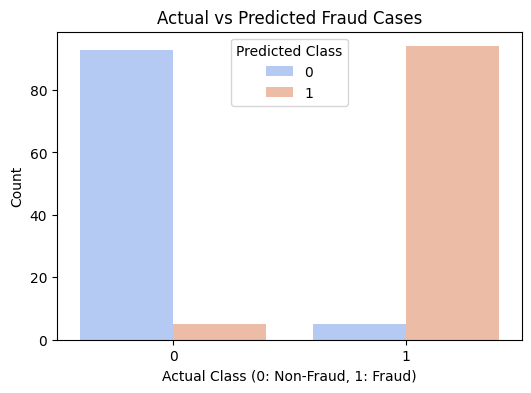

In [16]:
plt.figure(figsize=(6, 4))

comparison_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})

sns.countplot(data=comparison_df, x="Actual", hue="Predicted", palette="coolwarm")

plt.xlabel("Actual Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Count")
plt.title("Actual vs Predicted Fraud Cases")
plt.legend(title="Predicted Class")
plt.show()

# Predictions

### Test Data

In [17]:
test_data1 = pd.DataFrame({
    "Time": [78396.99],
    "Amount": [5378.87],
    "PC1": [2.15],
    "PC2": [-0.95],
    "PC3": [1.50],
})

test_data2 = pd.DataFrame({
    "Time": [28692.00],
    "Amount": [99.99],
    "PC1": [-1.78], 
    "PC2": [1.23], 
    "PC3": [-0.50],
})

test_data3 = pd.DataFrame({
    "PC1": [-1.50],
    "PC2": [0.45],
    "PC3": [-0.25],
    "Time": [34567.89],
    "Amount": [15.00],
})

### Predictions

In [18]:
# For test data 1
prediction1 = ensemble_model.predict(test_data1.to_numpy())
print("Prediction:", prediction1[0])

#For test data 2
prediction2 = ensemble_model.predict(test_data2.to_numpy())
print("Prediction:", prediction2[0])

#For test data 3
prediction3 = ensemble_model.predict(test_data3.to_numpy())
print("Prediction:", prediction3[0])

Prediction: 0
Prediction: 0
Prediction: 1


# Generating pickle file

In [20]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(ensemble_model, f)

print("✅ model.pkl saved!")

✅ model.pkl saved!
